# ROS Robot Motion Control
## Modeling and Control of Robotic Manipulators

Reminder: Follow the steps in the instruction files in the moodle course for using VM, ROS and Matlab

In [1]:
%matplotlib widget
import os
import sys
sys.path.append("/opt/ros/noetic/lib/python3/dist-packages")
import scipy
import numpy as np
import roboticstoolbox as rtb
from spatialmath import SE3
from spatialmath.base import *
import rospy
from trajectory_msgs.msg import JointTrajectory, JointTrajectoryPoint
from sensor_msgs.msg import JointState
import time
import matplotlib.pyplot as plt

from helperFunctions import JointVec2JointTrajectoryMsg, JointVec2FollowJointTrajectoryMsg

name_list = ["shoulder_pan_joint","shoulder_lift_joint","elbow_joint","wrist_1_joint","wrist_2_joint","wrist_3_joint"]
jointStateMsg = JointState()

def jointStateCallback(msg):
    global jointStateMsg
    jointStateMsg = msg

## Inverse Kinematics
### 1.    Inverse Kinematics
Generate an inverse kinematics solver object `iksolver` for the rigid body tree object _ur_.

In [2]:
# import ur10.urdf
notebook_path = os.getcwd()
ur10_file_path = notebook_path + "/ur10.urdf"
ur10 = rtb.Robot.URDF(ur10_file_path)

# initialize an inverse kinematic solver
mask = [1, 1, 1, 1, 1, 1]
ik = rtb.IK_LM(mask = mask)

### 2. Define a target pose
Define a target pose in terms of a transform _tformTargetPose_ that results from a translation $[d_x \ d_y \ d_z]^T =[0.6 \ 0 \ 1.0]^T$ and a rotation by Euler angles $[\phi \ \theta \ \psi]^T=[\pi/4  \ \pi/4  \ -\pi/4]^T$.

In [3]:
targetPosition = [0.6, 0, 1.0]
targetOrientation = [-np.pi / 4, np.pi / 4, np.pi / 4]

tformTrans = SE3(0.6, 0, 1.0)
tformRot = SE3(rpy2tr(-np.pi/4, np.pi/4, np.pi/4))
tformTargetPose = tformTrans @ tformRot
print(tformTargetPose)

   0.5      -0.8536   -0.1464    0.6       
   0.5       0.1464    0.8536    0         
  -0.7071   -0.5       0.5       1         
   0         0         0         1         



### 3. Determine the targetConf with the initialized ikSolver object above
Determine the inverse kinematics solution targetConf with the method `ik.solve` for the target pose of the end effector link frame _'ee_link'_ with a unit error weight vector $w=[1 \ 1 \ 1 \ 1 \ 1 \ 1]$. 

In [4]:
initial_guess = [0, 1, -2, 2, 1, 1]
targetConf, _, _, _, _, _ = ik.solve(ur10.ets(), tformTargetPose, initial_guess)
print(targetConf)

[-0.38244612  0.98038946 -2.00329962  2.21999805  0.86258962  1.32790853]


## ROS
### 4. Simulate the UR robot motion in Gazebo
To simulate the UR robot motion in Gazebo invoke the following launch files:

    roslaunch ur_launch ur10_sim_gazebo.launch rqt:=false

The launch file starts Gazebo (hidden), RViz and the ROS controllers without the RQT interface.	

### 5. Connect to ROS
Connect to the ROS master on the local host from within the Jupyter Notebook with `rospy.init_node`

In [5]:
import os
import subprocess

# Set the ROS environment variables
ros_env = {
    "PKG_CONFIG_PATH": "/home/samira/my_workspace/devel/lib/pkgconfig:/opt/ros/noetic/lib/pkgconfig:/opt/ros/noetic/lib/x86_64-linux-gnu/pkgconfig",
    "ROS_PACKAGE_PATH": "/home/samira/my_workspace/src:/opt/ros/noetic/share",
    "ROS_ETC_DIR": "/opt/ros/noetic/etc/ros",
    "CMAKE_PREFIX_PATH": "/home/samira/my_workspace/devel:/opt/ros/noetic",
    "PYTHONPATH": "/home/samira/my_workspace/devel/lib/python3/dist-packages:/opt/ros/noetic/lib/python3/dist-packages",
    "LD_LIBRARY_PATH": "/home/samira/my_workspace/devel/lib:/opt/ros/noetic/lib:/opt/ros/noetic/lib/x86_64-linux-gnu",
    "PATH": "/opt/ros/noetic/bin:/home/samira/.local/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin",
    "ROS_ROOT": "/opt/ros/noetic/share/ros",
}

# Update the current environment with the ROS environment variables
os.environ.update(ros_env)

In [6]:

rospy.init_node('notebook',  anonymous=True)
time.sleep(1)  

### 6. Show topics
Query the topics that are currently available on the network and obtain information about the topic _'/ur10/joint_states'_ in particular the message type.

You notice that the JointStatePublisher publishes on the topic _'/ur10/joint_states'_

In [7]:
# rostopic list
# rostopic info /ur10/joint_states
# rostopic info ur10/vel_based_pos_traj_controller/command
topic_list = rospy.get_published_topics()
print(topic_list)

[['/rosout_agg', 'rosgraph_msgs/Log'], ['/rosout', 'rosgraph_msgs/Log'], ['/tf', 'tf2_msgs/TFMessage'], ['/tf_static', 'tf2_msgs/TFMessage'], ['/ur10/joint0_velocity_controller/command', 'std_msgs/Float64'], ['/ur10/joint1_velocity_controller/command', 'std_msgs/Float64'], ['/ur10/joint2_velocity_controller/command', 'std_msgs/Float64'], ['/ur10/joint3_velocity_controller/command', 'std_msgs/Float64'], ['/ur10/joint4_velocity_controller/command', 'std_msgs/Float64'], ['/ur10/joint5_velocity_controller/command', 'std_msgs/Float64'], ['/ur_distance_publisher/collision_distance_marker', 'visualization_msgs/Marker'], ['/ur_distance_publisher/collision_point_marker', 'visualization_msgs/Marker'], ['/ur_distance_publisher/minimum_distances', 'robot_utilities/MsgDistances'], ['/ur10_task_planner/task_waypoint_marker/feedback', 'visualization_msgs/InteractiveMarkerFeedback'], ['/robot_workspace_monitor/interactive_obstacle_marker/feedback', 'visualization_msgs/InteractiveMarkerFeedback'], ['/u

### 7. Instantiate a subscriber for the topic above and receive messages
Instantiate a subscriber in the Jupyter Notebook for this topic and receive a message for the joint states.

Inspect the field _jointstate.Position_ which denotes the vector of joint variables. The first six elements correspond to joints _shoulder_pan_joint_ to _wrist_3_joint_.

In [8]:
rospy.Subscriber('/ur10/joint_states', JointState,jointStateCallback)


## Trajectory Control via Topic Interface
### 8. Information about ros message and helper function
Trajectory commands of message type _trajectory_msgs/JointTrajectory_ are published on the topic  _/ur10/vel_based_pos_traj_controller/command_. Notice that the function `jointStateCallback` saves the received messages in a global variable _jointStateMsg_.

The message type has the components _Header_, _JointNames_ and _Points_. _JointNames_ refer to the joint names in the URDF description of the robot. _Points_ is an array of waypoints (_JointTrajectoryPoint_) that constitutes the sequence of poses plus time intervals the robot is supposed to track. Each _JointTrajectoryPoint_ of message type _trajectory_msgs/TrajectoryPoint_ has the components _Positions, Velocities and Accelerations_ which correspond to joint state vector $\mathbf{q}$, joint velocity vector $\dot{\mathbf{q}}$ and joint acceleration vector $\ddot{\mathbf{q}}$. The component _TimeFromStart_ specifies the time stamp of the waypoint, relative to the message time defined in the header of the _trajectory_msgs/JointTrajectory_ message.

The helper function 

		JointVec2JointTrajectoryMsg(q, t)

maps the $n \times m$ arrays of joint vectors _q_,  joint velocities _qvel_ and joint accelerations _qacc_ and the $n \times 1$ vector of time stamps onto the corresponding joint trajectory message. The input argument _qvel_ and _qacc_ are optional and assume default zero values if omitted. 

### 9. Perform a point to point motion
Perform a point-to-point motion from the current configuration to the target configuration from task 3.

In [9]:
# create publisher
jointTrajectoryPub = rospy.Publisher(
    "/ur10/vel_based_pos_traj_controller/command", JointTrajectory, queue_size=10
)

# convert target configuration
q_target = targetConf
t_target = 2.5

# time offset to let robot finish motion
t_offset = 3 # increase if robot does not reach it's configuration in time

# send target configuration to the robot
jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_target, t_target)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

time.sleep(t_target + t_offset)

### 10. Execute the rated loop that monitors the temporal evaluation of the joint state vector
The motion command is executed in a fire and forget manner. Replace the pause command with a rated loop that monitors the temporal evolution of the joint state vector by subscribing to the _/ur10/joint_states_ topic. 
Access the robots state and velocity from the _jointStateMsg_

        jointState = jointStateMsg.position
        jointVel = jointStateMsg.velocity

In [10]:
# Move to start configuration
q_home = np.array([0, 0, 0, 0, 0, 0])
t_home = 2.5

jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_home, t_home)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

time.sleep(t_home + t_offset)
# Define target joint position and joint velocity
qvel = np.array([0, 0, 0, 0, 0, 0])

# Create rate object
rate = 50
# Hz
# rateObj=robotics.Rate(rate)
rateObj = rospy.Rate(rate)
tf = t_target + 0.5
# rateObj.reset; # reset time of rate object

# Preallocation
N = int(tf * rate)
timeStamp = np.zeros((N, 1))
jointStateStamped = np.zeros((N, 6))  # array to record joint pose
jointVelStamped = np.zeros((N, 6))  # array to record joint velocity

# Store start time
t0 = jointStateMsg.header.stamp.to_sec()

# Move and monitor
jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_target, t_target, qvel)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

for i in range(1, N):
    # Receive and convert
    jointState = jointStateMsg.position
    jointVel = jointStateMsg.velocity
    # Store signals
    jointStateStamped[i, :] = jointState
    jointVelStamped[i, :] = jointVel
    timeStamp[i] = jointStateMsg.header.stamp.to_sec() - t0  # + msg_time*10^-9

    rateObj.sleep()

### 11.	Plot the joint state and joint velocity
Plot the joint state and joint velocity vector versus time as shown in figure 3. The joint motion profile is quintic to guarantee continuity of joint state, velocities and accelerations at way-points.

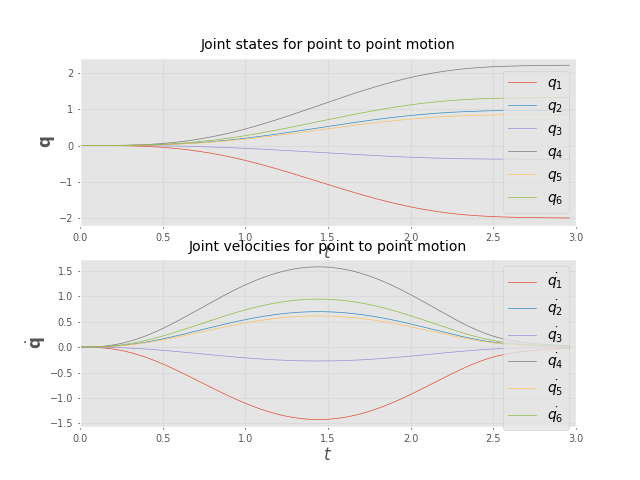

In [11]:
plt.figure(1)

# Plot joint states
plt.subplot(211)
plt.xlim([0, 3])
for i in range(jointStateStamped.shape[1]):
    plt.plot(timeStamp, jointStateStamped[:, i], label=f"$q_{i+1}$")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\mathbf{q}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint states for point to point motion")
plt.grid(True)

# Plot joint velocities
plt.subplot(212)
plt.xlim([0, 3])
for i in range(jointVelStamped.shape[1]):
    plt.plot(timeStamp, jointVelStamped[:, i], label=f"$\dot{{q_{i+1}}}$")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\dot{\mathbf{q}}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint velocities for point to point motion")
plt.grid(True)

# plt.tight_layout()
plt.show()

### 12.	Prepare a motion via two way-points
A general trajectory is composed of a sequence of way-points. The joint trajectory commands accept multiple joint configurations with time stamps to be traversed in that order. Command a trajectory  composed of the intermediate way-point $\mathbf{q}_{target}$ and final way-point $\mathbf{q}_2=[-1 \ 0 \ -1 \ 1 \ 0 \ 2]$. 

In [12]:
# Back to home
jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_home, t_home)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

time.sleep(t_home + t_offset)

# Create second waypoint
t_targets = [2.5, 6.0]
qf = np.array([-1, 0, -1, 1, 0, 2])
q_targets = np.vstack((np.array(q_target), qf))

# task='12'
task = "12"

if task == "12":
    # stop at intermediate way-point
    qvel = np.zeros((2,6))  # stop at intermediate way-point

elif task == "14":
    # stop at intermediate way-point
    q_avg = (qf - q_target) / t_targets[1]
    qvel1 = 2 * q_avg
    qvelf = np.zeros(6)
    qvel = np.vstack([qvel1, qvelf])

### 13.	Perform motion via two way-points
Command, record and plot the joint motion through multiple way-points with the same code as for the point to point motion. Notice, that 

	JointVec2JointTrajectoryMsg(robot, q, t, qvel, qacc)

accepts, a matrix of way-points q and a vector of time instances t. The motion is shown in figure 4. Notice, that the joint velocities at the intermediate way-point go to zero. This is desirable for joints $q_2,q_5$ which either stop or undergo a motion reversal at the first way-point. However, it seems awkward that joints $q_1,q_4$ come to a stop before continuing their movement.

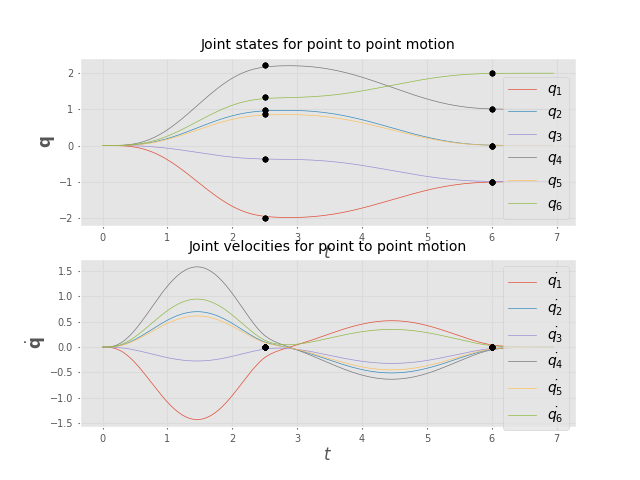

In [13]:
tf = t_targets[-1] + 1.0
# rateObj.reset; # reset time of rate object

# Preallocation
N = int(tf * rate)
timeStamp = np.zeros((N, 1))
jointStateStamped = np.zeros((N, 6))  # array to record joint pose
jointVelStamped = np.zeros((N, 6))  # array to record joint velocity

# Store start time
t0 = jointStateMsg.header.stamp.to_sec()

# Move and monitor

jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_targets, t_targets, qvel)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

for i in range(1, N):
    # Receive and convert
    # jointStateMsg=jointStateSub.receive();
    # [jointState, jointVel]=JointStateMsg2JointState(ur10,jointStateMsg);
    jointState = jointStateMsg.position
    jointVel = jointStateMsg.velocity

    # Store signals
    jointStateStamped[i, :] = jointState
    jointVelStamped[i, :] = jointVel
    timeStamp[i] = jointStateMsg.header.stamp.to_sec() - t0  # + msg_time*10^-9

    rateObj.sleep()

# Plot results
plt.figure(2)
plt.clf()
# Plot joint states
plt.subplot(211)
# plt.xlim([0, 3])
for i in range(jointStateStamped.shape[1]):
    plt.plot(timeStamp, jointStateStamped[:, i], label=f"$q_{i+1}$")

    for j in range(q_targets.shape[0]):
        plt.plot([t_targets[j]] * q_targets.shape[1], q_targets[j, :], "k.")

plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\mathbf{q}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint states for point to point motion")
plt.grid(True)

# Plot joint velocities
plt.subplot(212)
# plt.xlim([0, 2.5])
for i in range(jointVelStamped.shape[1]):
    plt.plot(timeStamp, jointVelStamped[:, i], label=f"$\dot{{q_{i+1}}}$")

    for j in range(qvel.shape[0]):
        plt.plot([t_targets[j]] * qvel.shape[1], qvel[j, :], "k.")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\dot{\mathbf{q}}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint velocities for point to point motion")
plt.grid(True)

# plt.tight_layout()
plt.show()

### 14.	Modify the joint trajectory from task 12 and perform task 12 and 13
Modify the joint trajectory command by imposing a velocity vector  for the first way-point. Notice, that for a smooth motion the joint velocities  should assume their maximum at the first way-point. The maximum velocity equals is twice as large as the average velocity given by 
\begin{equation}
\mathbf{q}_{avg}=\frac{\mathbf{q}_f-\mathbf{q}_i}{t_f}
\end{equation}
in which $q_f$ denotes the final joint state, $q_i$ the initial joint state and $t_f$ the total time of motion. The commanded velocity at the final way-point $\dot{\mathbf{q}}_2$ should still be zero for all joints as the motion is supposed to stop at the end of the trajectory. The motion with corrected way-point velocities is shown in figure 5.

## Trajectory Control via Action Server and Client
### 15. Display the current list of actions on the ROS network
Display the current list of actions on the ROS network. Confirm that there is an action _'/ur10/vel_based_pos_traj_controller/follow_joint_trajectory'_ and inspect the topic
Notice, that goal message is of type _control_msgs/FollowJointTrajectoryGoal_.

In [14]:
# rosaction list

# rosaction info '/ur10/vel_based_pos_traj_controller/follow_joint_trajectory'

### 16.	Instantiate an action client and an empty goal message
Instantiate an action client followJointTrajectoryActClient  for the action '/ur10/vel_based_pos_traj_controller/follow_joint_trajectory'.

In [15]:
# Bring in the SimpleActionClient
import actionlib
import control_msgs.msg

In [16]:
followJointTrajectoryTopicName = '/ur10/vel_based_pos_traj_controller/follow_joint_trajectory'
followJointTrajectoryActClient = actionlib.SimpleActionClient(
    followJointTrajectoryTopicName, control_msgs.msg.FollowJointTrajectoryAction
)
followJointTrajectoryActClient.wait_for_server()
followJointTrajectoryMsg = control_msgs.msg.FollowJointTrajectoryGoal()

In case you have problems to initiate the action client, set the ROS_IP in your virtual machine by hand.
Therefore, get the IP of your VM with 

    hostname -I

and then set the ROS_IP with the shown IP

    export ROS_IP=<outputHostname>

Note that you have to do this for every new terminal window, or add it to your bashrc.

### 17. Inspect the structure of the goal message
Inspect the structure of _followJointTrajectoryMsg_. The field _followJointTrajectoryMsg.Trajectory_ corresponds to	the message type that you previously used for the topic interface. The message contains additional specification for path, goal and time tolerance, to monitor the accuracy of the commanded motion. 

In [17]:
followJointTrajectoryMsg

trajectory: 
  header: 
    seq: 0
    stamp: 
      secs: 0
      nsecs:         0
    frame_id: ''
  joint_names: []
  points: []
path_tolerance: []
goal_tolerance: []
goal_time_tolerance: 
  secs: 0
  nsecs:         0

### 18.    Inspect the helper function 
The helper function 

    JointVec2FollowJointTrajectoryMsg(robot, q, t, qvel, qacc)

accepts a matrix of way-points _q_ (optional joint velocities _qvel_ and accelerations _qacc_) and a vector of time instances _t_ as input parameters and generates the corresponding _followJointTrajectoryMsg_.

### 19.    Follow a trajectory via the action client (blocking)
Generate a _followJointTrajectoryMsg_ from the previous waypoint sequence and inspect the message structure.
Send the trajectory command message _followJointTrajectoryMsg_ via the action client _followJointTrajectoryActClient_ and wait for the action server to complete the trajectory (Funcion `send_goal_and_wait(...)`). Inspect the _resultMsg_ and _resultState_ (Function `get_result()`).

In [18]:
# Back to home
jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_home, t_home)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

time.sleep(t_home + t_offset)

# Create action msg
followJointTrajectoryMsg = JointVec2FollowJointTrajectoryMsg(q_targets, t_targets, qvel)

# Send message
exec_timeout = rospy.Duration(10)
prmpt_timeout = rospy.Duration(5)

resultState = followJointTrajectoryActClient.send_goal_and_wait(
    followJointTrajectoryMsg, exec_timeout, prmpt_timeout)
resultMsg = followJointTrajectoryActClient.get_result()

# Evaluate result
if (resultMsg.error_code):
    print('Arm motion error')
    print(resultMsg)
else:
    print('UR arm motion completed with state ' + str(resultState) + '.')

UR arm motion completed with state 3.


### 20.    Follow a trajectory via the action client (non blocking)
Generate a _followJointTrajectoryMsg_ from the previous waypoint sequence and inspect the message structure.
Send the trajectory command message _followJointTrajectoryMsg_ via the action client _followJointTrajectoryActClient_ (Function `send_goal`). Inspect the _resultMsg_ and _resultState_. Note that you pass an callback (`done_cb`) for the result message as an argument to the function `send_goal`.

In [19]:
# Back to home
jointTrajectoryMsg = JointVec2JointTrajectoryMsg(q_home,t_home)
jointTrajectoryMsg.header.stamp = rospy.Time.now()
jointTrajectoryPub.publish(jointTrajectoryMsg)

time.sleep(t_home + t_offset)

# Create action msg
followJointTrajectoryMsg = JointVec2FollowJointTrajectoryMsg(q_targets, t_targets, qvel)

# Send message
exec_timeout = rospy.Duration(10)
prmpt_timeout = rospy.Duration(5)

finished = False

def done_cb(status, result):
    global finished, resultMsg
    finished = True
    resultMsg = result

timeStamp=[]
jointStateStamped=[]
jointVelStamped=[]
t0 = jointStateMsg.header.stamp.to_sec()
resultState = followJointTrajectoryActClient.send_goal(followJointTrajectoryMsg, done_cb)
i = 0

while not finished:


    # Receive and convert
    #jointStateMsg=jointStateSub.receive()
    #[jointState, jointVel]=JointStateMsg2JointState(ur10,jointStateMsg);
    jointState = jointStateMsg.position
    jointVel = jointStateMsg.velocity
    
    # Store signals
    jointStateStamped.append(jointState)
    jointVelStamped.append(jointVel)
    timeStamp.append(jointStateMsg.header.stamp.to_sec() - t0)# + msg_time*10^-9
    rateObj.sleep()
    i+=1
jointStateStamped = np.stack(jointStateStamped, axis=0)
jointVelStamped = np.stack(jointVelStamped, axis=0)
timeStamp = np.stack(timeStamp, axis=0)
# Evaluate result
if (resultMsg.error_code):
    print('Arm motion error')
    print(resultMsg)
else:
    print('UR arm motion completed with state ' + str(resultState) + '.')

UR arm motion completed with state None.


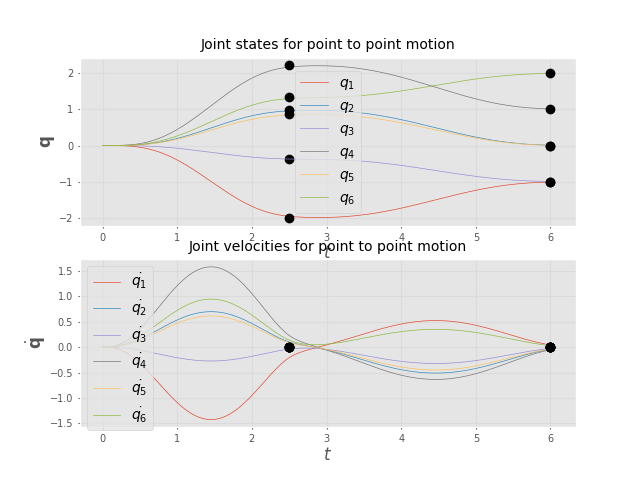

In [20]:
# Plot results
plt.figure(2)
plt.clf()
# Plot joint states
plt.subplot(211)
# plt.xlim([0, 3])
for i in range(jointStateStamped.shape[1]):
    plt.plot(timeStamp, jointStateStamped[:, i], label=f"$q_{i+1}$")

    for j in range(q_targets.shape[0]):
        plt.plot(t_targets[j], q_targets[j, i], "ko")

plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\mathbf{q}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint states for point to point motion")
plt.grid(True)

# Plot joint velocities
plt.subplot(212)
# plt.xlim([0, 2.5])
for i in range(jointVelStamped.shape[1]):
    plt.plot(timeStamp, jointVelStamped[:, i], label=f"$\dot{{q_{i+1}}}$")

    for j in range(qvel.shape[0]):
        plt.plot(t_targets[j], qvel[j, i], "ko")
plt.xlabel("$t$", fontsize=12)
plt.ylabel("$\dot{\mathbf{q}}$", fontsize=12)
plt.legend(loc="best", fontsize=10)
plt.title("Joint velocities for point to point motion")
plt.grid(True)

# plt.tight_layout()
plt.show()